In [11]:
import urllib.parse
import xml.etree.ElementTree as ET
import requests
from tqdm import tqdm
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# 그래프에 한글폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'

# 유니코드에서 그래프에 마이너스 기호 깨지는 문제 해결
plt.rcParams['axes.unicode_minus'] = False

### Primary Regional Legal Dong Codes (`LAWD_CD`) Reference

Use these 5-digit regional codes for the `LAWD_CD` parameter when calling the API:

#### 1. Seoul (서울특별시)
| District (구) | `LAWD_CD` | District (구) | `LAWD_CD` |
| :--- | :--- | :--- | :--- |
| 종로구 (Jongno-gu) | `11110` | 도봉구 (Dobong-gu) | `11320` |
| 중구 (Jung-gu) | `11140` | 노원구 (Nowon-gu) | `11350` |
| 용산구 (Yongsan-gu) | `11170` | 은평구 (Eunpyeong-gu) | `11380` |
| 성동구 (Seongdong-gu) | `11200` | 서대문구 (Seodaemun-gu) | `11410` |
| 광진구 (Gwangjin-gu) | `11215` | 마포구 (Mapo-gu) | `11440` |
| 동대문구 (Dongdaemun-gu) | `11230` | 양천구 (Yangcheon-gu) | `11470` |
| 중랑구 (Jungnang-gu) | `11260` | 강서구 (Gangseo-gu) | `11500` |
| 성북구 (Seongbuk-gu) | `11290` | 구로구 (Guro-gu) | `11530` |
| 금천구 (Geumcheon-gu) | `11545` | 동작구 (Dongjak-gu) | `11590` |
| 영등포구 (Yeongdeungpo-gu) | `11560` | 관악구 (Gwanak-gu) | `11620` |
| 서초구 (Seocho-gu) | `11650` | 강남구 (Gangnam-gu) | `11680` |
| 송파구 (Songpa-gu) | `11710` | 강동구 (Gangdong-gu) | `11740` |

---

#### 2. Gyeonggi-do (경기도)
| Major City / District (시/구) | `LAWD_CD` | Major City / District (시/구) | `LAWD_CD` |
| :--- | :--- | :--- | :--- |
| 수원시 장안구 (Suwon Jangan) | `41111` | 성남시 수정구 (Seongnam Sujeong) | `41131` |
| 수원시 권선구 (Suwon Gwonseon) | `41113` | 성남시 중원구 (Seongnam Jungwon) | `41133` |
| 수원시 팔달구 (Suwon Paldal) | `41115` | 성남시 분당구 (Seongnam Bundang) | `41135` |
| 수원시 영통구 (Suwon Yeongtong)| `41117` | 부천시 (Bucheon) | `41190` |
| 고양시 덕양구 (Goyang Deogyang) | `41281` | 안양시 만안구 (Anyang Manan) | `41171` |
| 고양시 일산동구 (Goyang Ilsandong)| `41285` | 안양시 동안구 (Anyang Dongan) | `41173` |
| 고양시 일산서구 (Goyang Ilsanseo) | `41287` | 용인시 처인구 (Yongin Cheoin) | `41461` |
| 용인시 기흥구 (Yongin Giheung) | `41463` | 용인시 수지구 (Yongin Suji) | `41465` |
| 화성시 (Hwaseong) | `41590` | 하남시 (Hanam) | `41450` |
| 과천시 (Gwacheon) | `41290` | 광명시 (Gwangmyeong) | `41210` |

---

#### 3. Major Metropolitan Cities (주요 광역시 및 특례시)
| City / Region (광역시/지역) | `LAWD_CD` | City / Region (광역시/지역) | `LAWD_CD` |
| :--- | :--- | :--- | :--- |
| 인천 중구 (Incheon Jung-gu) | `28110` | 대구 수성구 (Daegu Suseong-gu) | `27260` |
| 인천 연수구 (Incheon Yeonsu) | `28185` | 대전 유성구 (Daejeon Yuseong-gu)| `30200` |
| 부산 해운대구 (Busan Haeundae) | `26350` | 광주 서구 (Gwangju Seo-gu) | `29140` |
| 부산 수영구 (Busan Suyeong-gu) | `26500` | 세종특별자치시 (Sejong) | `36110` |

> **Note:** To look up additional specific 5-digit legal dong codes, visit the [Administrative Code Management System](https://www.code.go.kr).

## Download new data

In [49]:
# 1. API 기본 설정
url = "http://apis.data.go.kr/1613000/RTMSDataSvcAptTradeDev/getRTMSDataSvcAptTradeDev"

# 서비스 키 입력 (Decoding / Encoding 키 모두 처리 가능)
raw_service_key = "API_KEY"
service_key = urllib.parse.unquote(raw_service_key)

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# 2. 조회 조건 설정
lawd_cd = "11650"          # (원하는 법정동코드 5자리)
start_ymd = "202501"       # 시작년월
end_ymd = "202609"         # 종료년월

# 월별 조회 리스트 생성
date_range = pd.date_range(start=start_ymd + "01", end=end_ymd + "01", freq="MS").strftime("%Y%m").tolist()

all_records = []

# 3. 데이터 반복 수집
for deal_ymd in tqdm(date_range):
    print(f"Fetching data for YYYYMM: {deal_ymd}...")
    page_no = 1
    
    while True:
        params = {
            "serviceKey": service_key,
            "LAWD_CD": lawd_cd,
            "DEAL_YMD": deal_ymd,
            "pageNo": str(page_no),
            "numOfRows": "100"
        }
        
        response = requests.get(url, params=params, headers=headers)
        
        if response.status_code != 200:
            print(f"HTTP Error {response.status_code} on {deal_ymd}")
            break
            
        try:
            root = ET.fromstring(response.content)
            
            # API 결과 코드 확인 (00, 0, 000 모두 정상으로 간주)
            result_code_elem = root.find(".//resultCode")
            if result_code_elem is not None:
                res_code = result_code_elem.text.strip() if result_code_elem.text else ""
                if res_code not in ["00", "0", "000", "NORMAL_SERVICE"]:
                    result_msg = root.find(".//resultMsg").text if root.find(".//resultMsg") is not None else ""
                    print(f"API Real Error [{res_code}]: {result_msg}")
                    break

            items = root.findall(".//item")
            if not items:
                break  # 해당 월 데이터 수집 완료
                
            # XML item 하위의 모든 Raw 컬럼을 동적 추출
            for item in items:
                row_dict = {}
                for child in item:
                    row_dict[child.tag] = child.text.strip() if child.text else None
                all_records.append(row_dict)
                
            # 페이지네이션 체크
            total_count_elem = root.find(".//totalCount")
            num_of_rows_elem = root.find(".//numOfRows")
            
            if total_count_elem is not None and num_of_rows_elem is not None:
                total_count = int(total_count_elem.text)
                num_of_rows = int(num_of_rows_elem.text)
                if page_no * num_of_rows >= total_count:
                    break
                page_no += 1
            else:
                break

        except ET.ParseError:
            print(f"XML Parsing Error for {deal_ymd}")
            break

# 4. 전체 데이터프레임 변환 및 전처리
df_combined = pd.DataFrame(all_records)

if not df_combined.empty:
    # 쉼표 제거 후 정수/실수형 변환
    if 'dealAmount' in df_combined.columns:
        df_combined['dealAmount_clean'] = (
            df_combined['dealAmount']
            .str.replace(',', '')
            .str.strip()
            .astype(float)
        )

    # 계약일자 날짜형 변환 (dealDate)
    if all(col in df_combined.columns for col in ['dealYear', 'dealMonth', 'dealDay']):
        df_combined['dealDate'] = pd.to_datetime(
            df_combined['dealYear'].astype(str) + '-' +
            df_combined['dealMonth'].astype(str).str.zfill(2) + '-' +
            df_combined['dealDay'].astype(str).str.zfill(2),
            errors='coerce'
        )

    # 수치형 필드 타입 정제
    numeric_cols = ['excluUseAr', 'floor', 'buildYear', 'bonbun', 'bubun']
    for col in numeric_cols:
        if col in df_combined.columns:
            df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')

    print(f"\n✅ 성공적으로 총 {len(df_combined)}건의 실거래 데이터를 통합했습니다.")
    print("데이터프레임 형태 (행, 열):", df_combined.shape)
    print("\n상위 5건 출력:")
    print(df_combined.head())
else:
    print("데이터가 수집되지 않았습니다.")

# save as csv
#df_combined.to_csv(f"data/apt_txns_data-{lawd_cd}_{start_ymd}_{end_ymd}.csv")

  0%|                                                    | 0/21 [00:00<?, ?it/s]

Fetching data for YYYYMM: 202501...


  5%|██                                          | 1/21 [00:01<00:23,  1.18s/it]

Fetching data for YYYYMM: 202502...


 10%|████▏                                       | 2/21 [00:03<00:35,  1.84s/it]

...

Fetching data for YYYYMM: 202608...


 95%|████████████████████████████████████████▉  | 20/21 [00:23<00:00,  1.12it/s]

Fetching data for YYYYMM: 202609...


100%|███████████████████████████████████████████| 21/21 [00:24<00:00,  1.15s/it]


✅ 성공적으로 총 4781건의 실거래 데이터를 통합했습니다.
데이터프레임 형태 (행, 열): (4781, 34)

상위 5건 출력:
  aptDong             aptNm      aptSeq  bonbun  bubun  buildYear buyerGbn  \
0    105동         래미안신반포팰리스  11650-4439     158      0       2016       개인   
1       6                임광   11650-341    1015      0       1985       개인   
2     202              서초힐스  11650-3821     773      0       2012       개인   
3     101              반포리체  11650-3617      30     26       2010       개인   
4     108  래미안방배아트힐(1008-2)   11650-658    1008      2       2004       개인   

  cdealDay cdealType dealAmount  ... roadNmCd roadNmSeq roadNmSggCd roadNmbCd  \
0                       355,000  ...  4163529        00       11650         0   
1                       264,500  ...  3121010        01       11650         0   
2                       144,500  ...  4163748        01       11650         0   
3                       353,000  ...  3121001        01       11650         0   
4                       228,000  ...  2000003      

## Recall saved data

In [66]:
all_files = glob.glob('data/apt_txns_data-*', recursive=True, include_hidden=True)
display(all_files)
data_list = []

for file in all_files:
    data = pd.read_csv(file)
    data_list.append(data)

raw_data = pd.concat(data_list).drop(columns=['Unnamed: 0'])
raw_data['dealDate'] = pd.to_datetime(raw_data['dealDate'])

df_combined = raw_data.copy()
df_combined['평_raw'] = df_combined['excluUseAr'] * 0.3025 # 평 수 변환
df_combined['평'] = np.round(df_combined['excluUseAr'] * 0.3025, 0) # 평 수 변환
df_combined['실거래가'] = df_combined['dealAmount_clean'].copy()
df_combined['평당_실거래가'] = df_combined['실거래가'] / df_combined['평']

['data/apt_txns_data-11650_202001_202412.csv',
 'data/apt_txns_data-11650_202501_202609.csv',
 'data/apt_txns_data-11650_201001_201412.csv',
 'data/apt_txns_data-11650_200501_200912.csv',
 'data/apt_txns_data-11650_201501_201912.csv']

### Apartment Trade Real Estate API Data - Column Reference

| Category | Column Name | Description (Korean) | Explanation |
| :--- | :--- | :--- | :--- |
| **Basic Info** | `aptNm` | 아파트명 | Name of the apartment complex |
| | `sggCd` | 시군구코드 | 5-digit municipal administrative district code |
| | `umdCd` | 읍면동코드 | 3-digit legal dong/neighborhood code |
| | `umdNm` | 법정동 | Name of the legal dong/neighborhood |
| | `jibun` | 지번 | Lot number address |
| | `bonbun` | 본번 | Primary lot number |
| | `bubun` | 부번 | Secondary lot number |
| | `aptDong` | 아파트 동 | Building block number/dong *(Only disclosed after ownership transfer registration)* |
| | `aptSeq` | 일련번호 | Unique apartment complex identifier code |
| | `buildYear` | 건축년도 | Construction completion year |
| **Physical Specs** | `excluUseAr` | 전용면적 | Exclusive living area in square meters ($\text{m}^2$) |
| | `floor` | 층 | Floor number of the apartment unit |
| | `landLeaseholdGbn` | 토지임대부 아파트 여부 | Land-leasehold apartment indicator (`Y`/`N`/`null`) |
| **Transaction Info** | `dealAmount` | 거래금액 | Transaction price in 10,000 KRW (e.g., `150,000` = 1.5 billion KRW) |
| | `dealYear` | 계약년 | Contract signature year (`YYYY`) |
| | `dealMonth` | 계약월 | Contract signature month (`MM`) |
| | `dealDay` | 계약일 | Contract signature day (`DD`) |
| | `dealingGbn` | 거래유형 | Transaction type (`직거래` for direct or `중개거래` for brokerage) |
| | `estateAgentSggNm` | 중개업소 소재지 | Municipal location of the real estate agency |
| | `slerGbn` | 매도자 구별 | Seller type (e.g., Individual, Corporate, Government) |
| | `buyerGbn` | 매수자 구별 | Buyer type (e.g., Individual, Corporate, Government) |
| **Status / Legal** | `cdealType` | 해제여부 | Contract cancellation flag (`O` if cancelled) |
| | `cdealDay` | 해제사유발생일 | Contract cancellation date (`YYYYMMDD`) |
| | `rgstDate` | 등기일자 | Ownership transfer registration completion date (`YY.MM.DD`) |
| **Road Address** | `roadNm` | 도로명 | Name of the street/road address |
| | `roadNmSggCd` | 도로명 시군구코드 | District code for road name address |
| | `roadNmCd` | 도로명 코드 | Unique street/road code |
| | `roadNmSeq` | 도로명 일련번호 | Road code sequence number |
| | `roadNmbCd` | 도로명 지상/지하 구분 | Ground/underground level indicator |
| | `roadNmBonbun` | 도로명 본번 | Primary building number under road name address |
| | `roadNmBubun` | 도로명 부번 | Secondary building number under road name address |
| **Feature Engineered** | `dealAmount_clean` | 정제된 거래금액 | Numeric transaction price cast to float (commas removed) |
| | `dealDate` | 계약일자 | Parsed datetime object (`YYYY-MM-DD`) from year, month, and day |

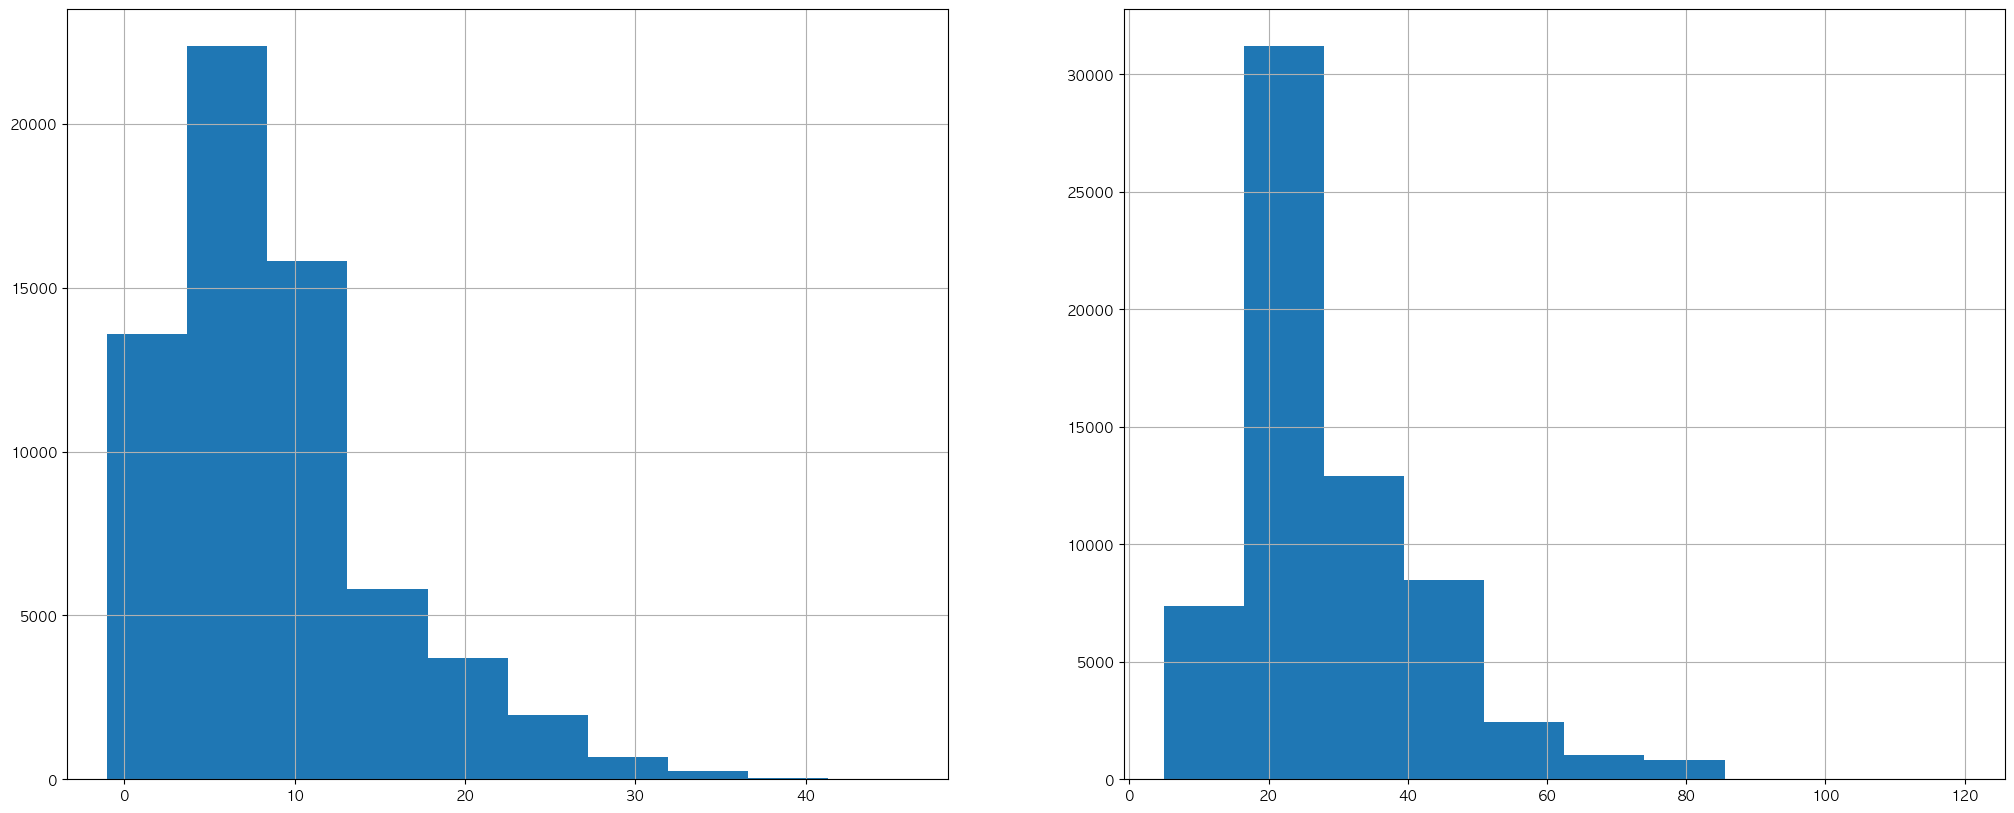

In [69]:
fig,ax = plt.subplots(1,2, figsize=(25,10))
df_combined['floor'].hist(ax=ax[0])
df_combined['평'].hist(ax=ax[1]);

In [71]:
# 평_group
condlist = [
    (df_combined['평'] >= 40), 
    (df_combined['평'] >= 30) & (df_combined['평'] < 40),
    (df_combined['평'] >= 20) & (df_combined['평'] < 30),
    (df_combined['평'] < 20)
]
choicelist = ['40평_이상', '30평_대', '20평_대', '20평_미만']
df_combined['평_group'] = np.select(condlist, choicelist, np.nan)

# floor_group
condlist = [
    (df_combined['floor'] >= 25),
    (df_combined['floor'] >= 15) & (df_combined['floor'] < 25),
    (df_combined['floor'] >= 5) & (df_combined['floor'] < 15),
    (df_combined['floor'] < 5)
]
choicelist = ['고층', '중상층', '중하층', '저층']
df_combined['floor_group'] = np.select(condlist, choicelist, np.nan)


display(df_combined['평_group'].value_counts(normalize=True))
display(df_combined['floor_group'].value_counts(normalize=True))

평_group
20평_대     0.395644
20평_미만    0.223263
40평_이상    0.198118
30평_대     0.182975
Name: proportion, dtype: float64

floor_group
중하층    0.547882
저층     0.288601
중상층    0.132530
고층     0.030987
Name: proportion, dtype: float64

In [73]:
평_group_names = ['Low', 'Medium-Low', 'Medium-High', 'High']
df_combined['평_group_qcut'] = pd.qcut(df_combined['평_raw'], q=4, labels=평_group_names)

floor_group_names = ['Low', 'Medium-Low', 'Medium-High', 'High']
df_combined['floor_group_qcut'] = pd.qcut(df_combined['floor'], q=4, labels=floor_group_names)

display(df_combined['평_group_qcut'].value_counts(normalize=True))
display(df_combined['floor_group_qcut'].value_counts(normalize=True))


평_group_qcut_table = pd.concat([
    df_combined.groupby(['평_group_qcut'])['평_raw'].min().rename('평_lower'),
    df_combined.groupby(['평_group_qcut'])['평_raw'].max().rename('평_upper')
], axis=1)

floor_group_qcut_table = pd.concat([
    df_combined.groupby(['floor_group_qcut'])['floor'].min().rename('floor_lower'),
    df_combined.groupby(['floor_group_qcut'])['floor'].max().rename('floor_upper')
], axis=1)

평_group_qcut_table['평_label'] = (
    np.array(평_group_qcut_table.index)
    + ": " 
    + np.round(평_group_qcut_table['평_lower'], 0).astype(str)
    + "-" 
    + np.round(평_group_qcut_table['평_upper'], 0).astype(str)
).str.replace(".0", "")

floor_group_qcut_table['floor_label'] = (
    np.array(floor_group_qcut_table.index)
    + ": " 
    + np.round(floor_group_qcut_table['floor_lower'], 0).astype(str)
    + "-" 
    + np.round(floor_group_qcut_table['floor_upper'], 0).astype(str)
).str.replace(".0", "")

display(평_group_qcut_table)
display(floor_group_qcut_table)

df_combined['평_group_qcut'] = df_combined['평_group_qcut'].replace(평_group_qcut_table['평_label'].to_dict())
df_combined['floor_group_qcut'] = df_combined['floor_group_qcut'].replace(floor_group_qcut_table['floor_label'].to_dict())

평_group_qcut
Medium-Low     0.257817
Low            0.250292
High           0.249560
Medium-High    0.242331
Name: proportion, dtype: float64

floor_group_qcut
Low            0.288601
Medium-High    0.270592
High           0.227827
Medium-Low     0.212980
Name: proportion, dtype: float64

,평_lower,평_upper,평_label
평_group_qcut,,,
Low,5.248375,21.864700,Low: 5-22
Medium-Low,21.867725,25.695258,Medium-Low: 22-26
Medium-High,25.697375,35.207975,Medium-High: 26-35
High,35.217050,119.505650,High: 35-120


,floor_lower,floor_upper,floor_label
floor_group_qcut,,,
Low,-1,4,Low: -1-4
Medium-Low,5,7,Medium-Low: 5-7
Medium-High,8,12,Medium-High: 8-12
High,13,46,High: 13-46


## 서초구 전체 평당 가격 추세

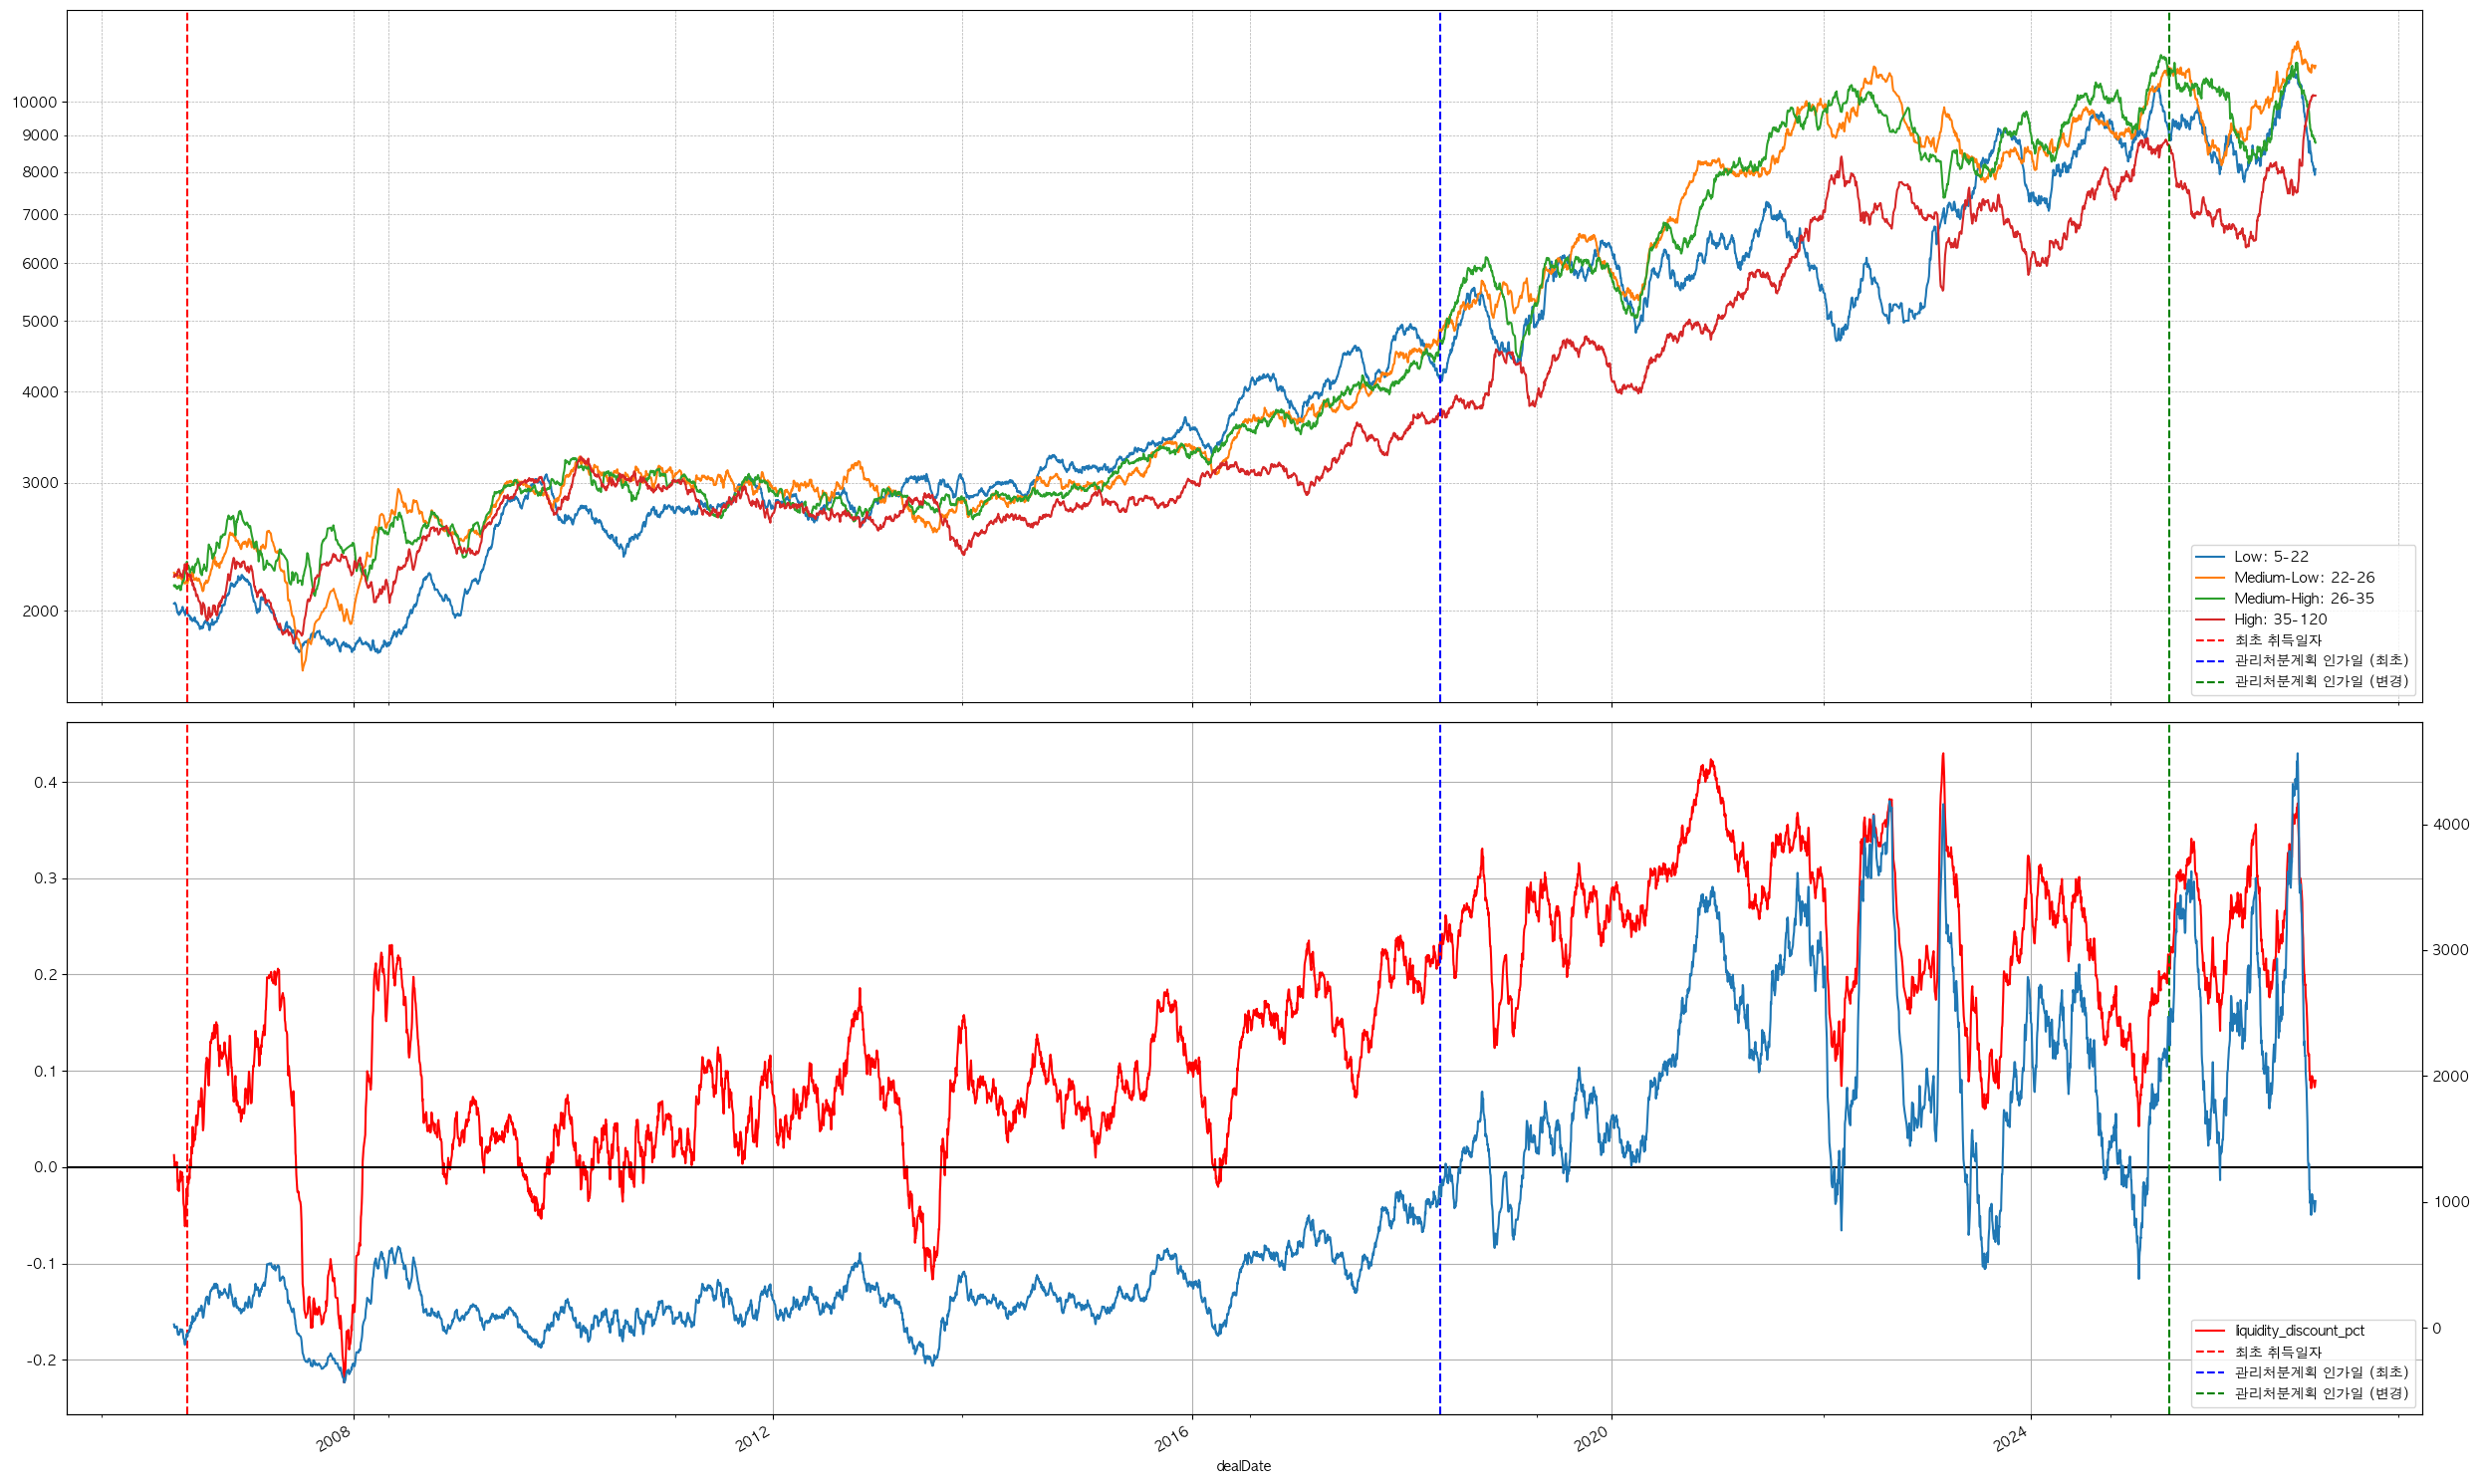

In [76]:
df_filtered = df_combined.copy()

seocho_ppp_by_pyung = (
    df_filtered.pivot_table(index='dealDate', columns=['평_group_qcut'], values='평당_실거래가', aggfunc='median')
    .ffill()
    .rolling(window=90).mean()
)

fig,ax = plt.subplots(2,1, figsize=(25, 15), sharex=True)


seocho_ppp_by_pyung.plot(ax=ax[0])
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)  # Shows major & minor log gridlines
ax[0].set_yscale('log')
ax[0].yaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].yaxis.set_minor_formatter(ticker.ScalarFormatter())

ax1 = ax[1].twinx()
seocho_ppp_by_pyung['liquidity_discount_abs'] = seocho_ppp_by_pyung['Medium-Low: 22-26'] - seocho_ppp_by_pyung['High: 35-120']
seocho_ppp_by_pyung['liquidity_discount_pct'] =  1 - seocho_ppp_by_pyung['High: 35-120'] / seocho_ppp_by_pyung['Medium-Low: 22-26']
seocho_ppp_by_pyung['liquidity_discount_pct'].plot(ax=ax[1], c='red')
seocho_ppp_by_pyung['liquidity_discount_abs'].plot(ax=ax1)
ax[1].axhline(0, c='black')
ax[1].grid()

purchase_date = pd.to_datetime('2006-06-01')
permit1_date = pd.to_datetime('2018-05-15')
permit2_date = pd.to_datetime('2025-04-25')

for i in range(len(ax)):
    ax[i].axvline(purchase_date, c='red', ls='--', label='최초 취득일자')
    ax[i].axvline(permit1_date, c='blue', ls='--', label='관리처분계획 인가일 (최초)')
    ax[i].axvline(permit2_date, c='green', ls='--', label='관리처분계획 인가일 (변경)')
    ax[i].legend()
plt.tight_layout();

## 서초구 전체 층당 가격 추세

floor_group_qcut,Low: -1-4,Medium-Low: 5-7,Medium-High: 8-12,High: 13-46,floor_discount_abs,floor_discount_pct
count,6928.000000,6928.000000,6928.000000,6926.000000,6928.000000,6928.000000
mean,4307.542270,4352.915289,4583.405463,5374.772406,45.373018,0.007070
std,2122.728506,2182.878135,2257.275269,3038.087594,548.101859,0.090331
min,1760.301661,1818.867436,1739.239979,1755.498388,-2726.826826,-0.486721
25%,2720.092334,2712.633939,2826.259054,3189.855000,-92.689920,-0.028892
50%,3225.434251,3236.962603,3444.550813,3755.973666,39.791534,0.013627
75%,6488.130636,6134.324345,6527.669191,7524.579817,205.209965,0.059014
max,9104.791486,10363.467223,9995.902769,13835.970298,2153.907928,0.222772


floor_group_qcut,Low: -1-4,Medium-Low: 5-7,Medium-High: 8-12,High: 13-46,floor_discount_abs,floor_discount_pct
dealDate,,,,,,
2006-06-01,2076.091657,2216.956102,2334.700354,2427.760496,140.864445,0.06354
2018-05-15,3800.791811,4290.556746,4388.156618,4433.487869,489.764936,0.11415
2025-04-25,8687.993136,9957.925616,9196.968350,11343.252678,1269.932480,0.12753


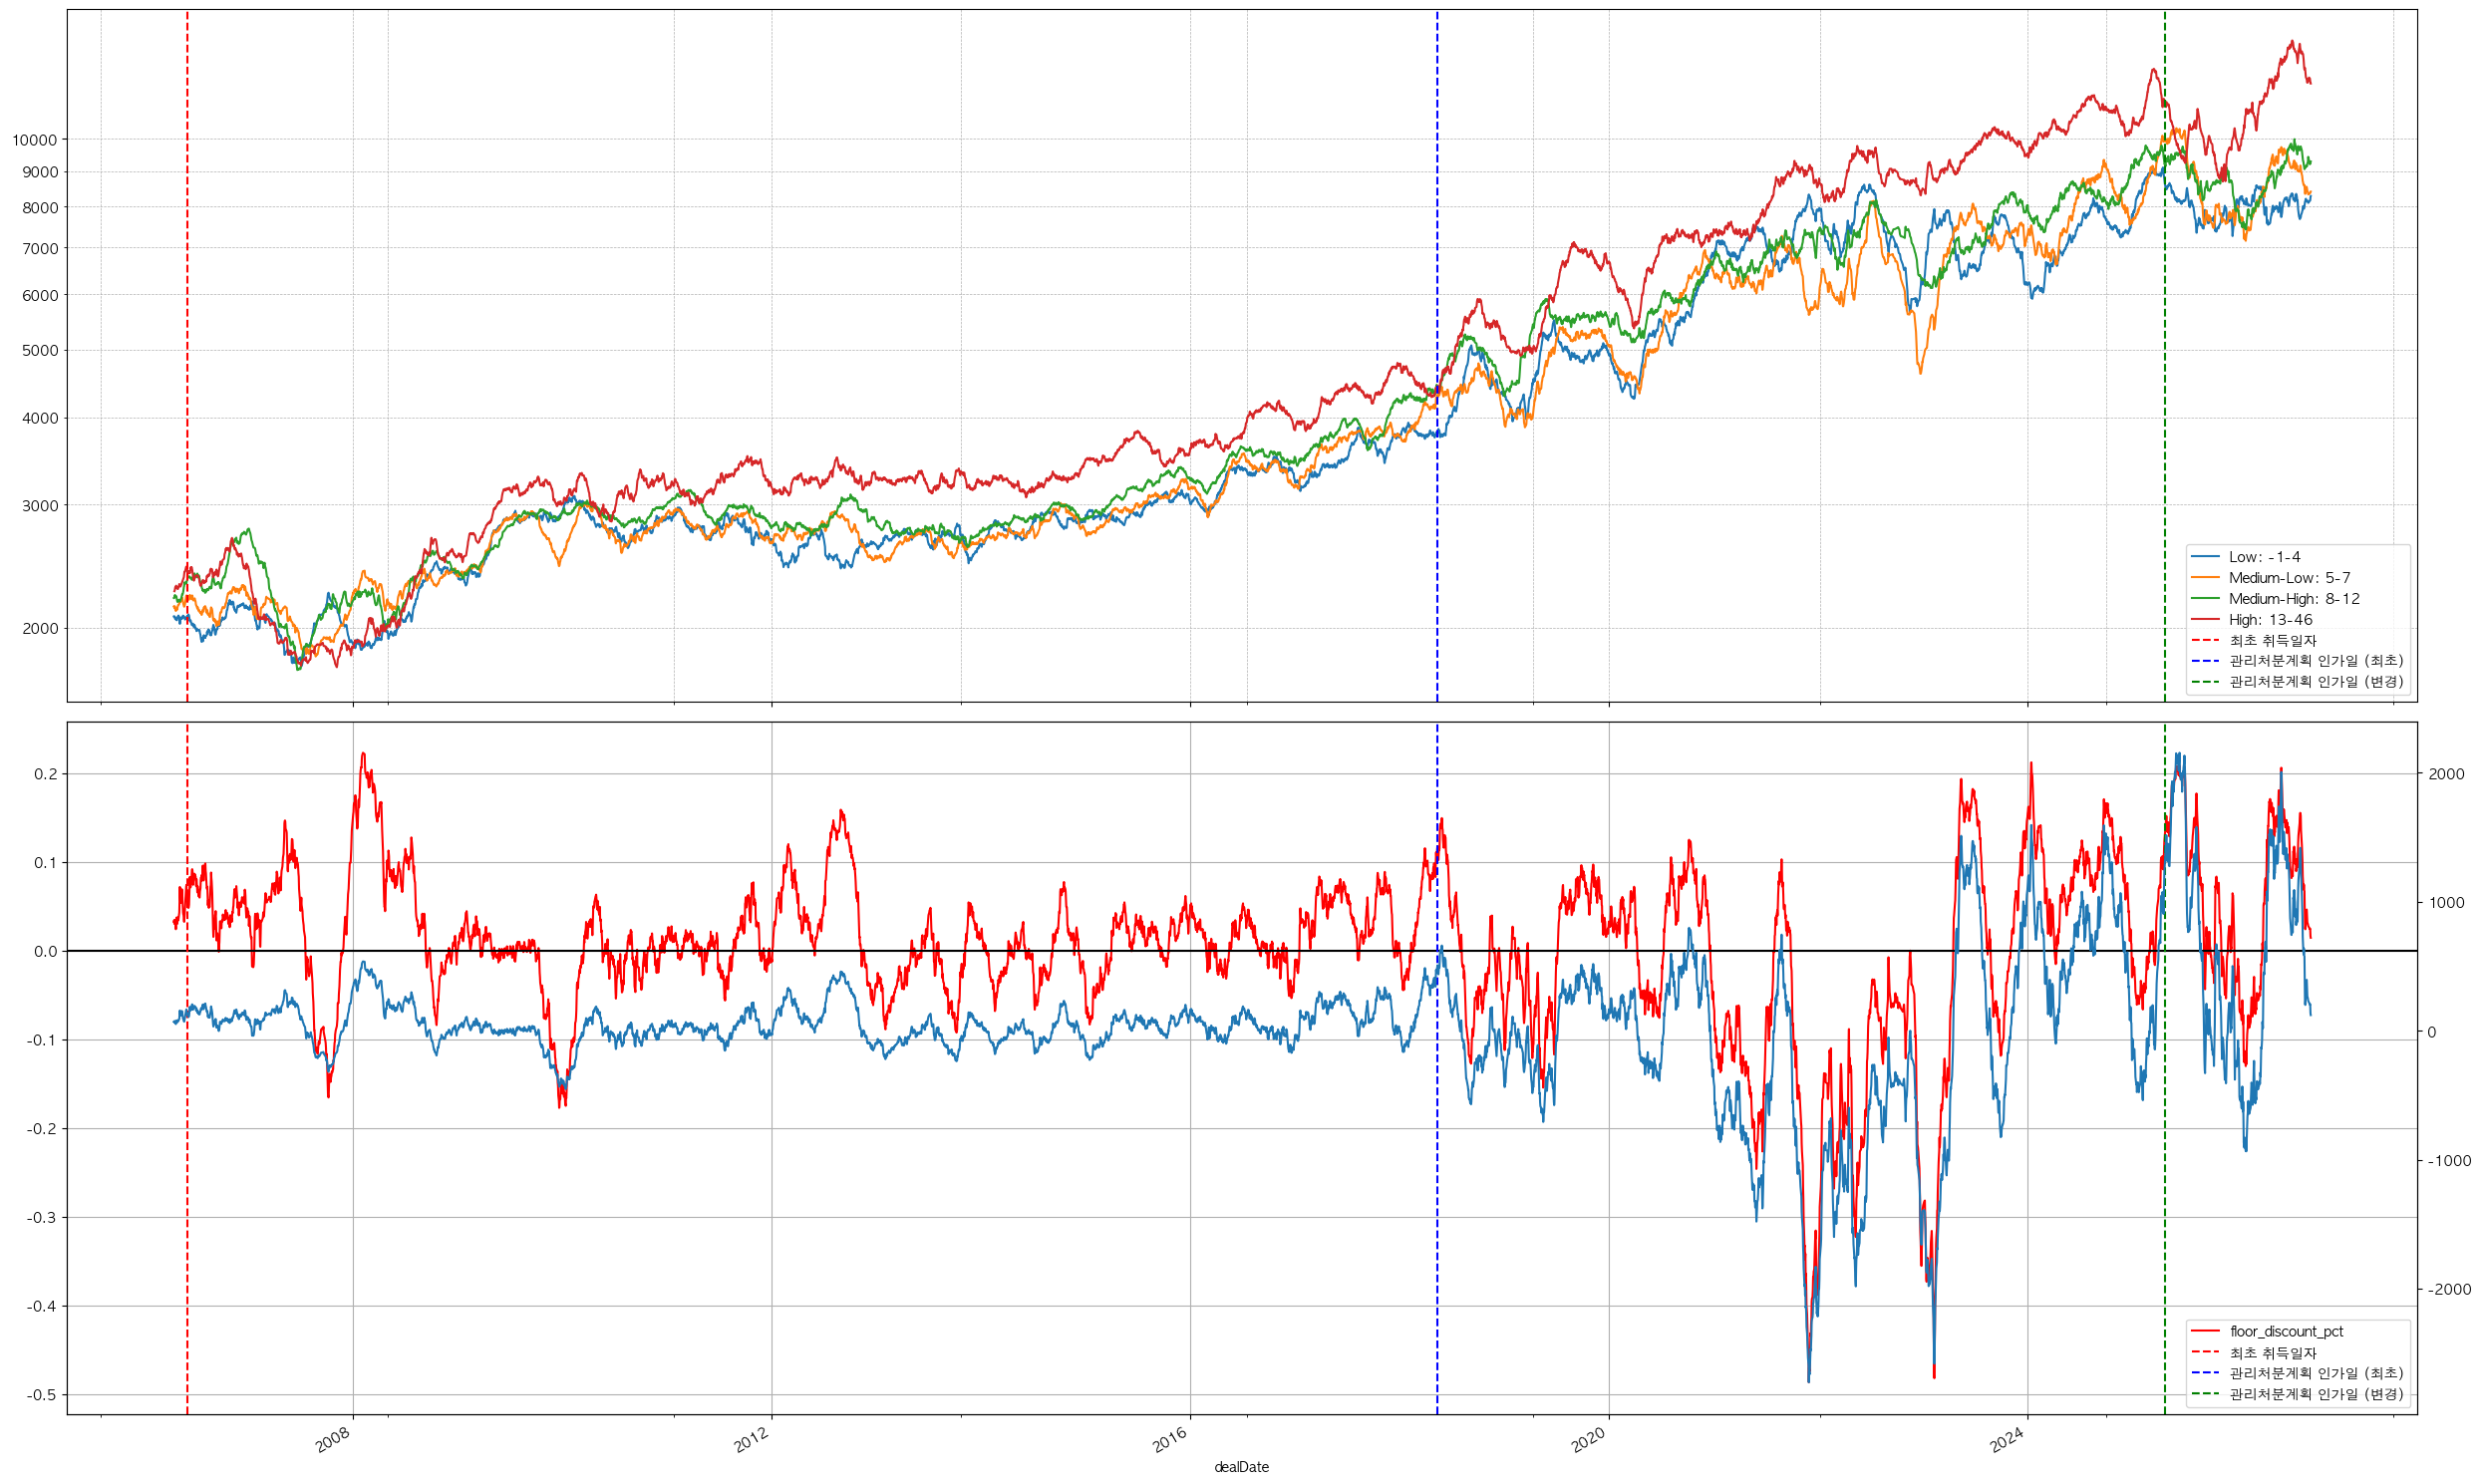

In [79]:
df_filtered = df_combined.copy()

seocho_ppp_by_floor = (
    df_filtered.pivot_table(index='dealDate', columns=['floor_group_qcut'], values='평당_실거래가', aggfunc='median')
    .ffill()
    .rolling(window=90).mean()
)


fig,ax = plt.subplots(2,1, figsize=(25, 15), sharex=True)


seocho_ppp_by_floor.plot(ax=ax[0])
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)  # Shows major & minor log gridlines
ax[0].set_yscale('log')
ax[0].yaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].yaxis.set_minor_formatter(ticker.ScalarFormatter())

ax1 = ax[1].twinx()
seocho_ppp_by_floor['floor_discount_abs'] = seocho_ppp_by_floor['Medium-Low: 5-7'] - seocho_ppp_by_floor['Low: -1-4']
seocho_ppp_by_floor['floor_discount_pct'] =  1 - seocho_ppp_by_floor['Low: -1-4'] / seocho_ppp_by_floor['Medium-Low: 5-7']
seocho_ppp_by_floor['floor_discount_pct'].plot(ax=ax[1], c='red')
seocho_ppp_by_floor['floor_discount_abs'].plot(ax=ax1)
ax[1].axhline(0, c='black')
ax[1].grid()

purchase_date = pd.to_datetime('2006-06-01')
permit1_date = pd.to_datetime('2018-05-15')
permit2_date = pd.to_datetime('2025-04-25')

for i in range(len(ax)):
    ax[i].axvline(purchase_date, c='red', ls='--', label='최초 취득일자')
    ax[i].axvline(permit1_date, c='blue', ls='--', label='관리처분계획 인가일 (최초)')
    ax[i].axvline(permit2_date, c='green', ls='--', label='관리처분계획 인가일 (변경)')
    ax[i].legend()
plt.tight_layout();

display(seocho_ppp_by_floor.describe())
display(seocho_ppp_by_floor.loc[[purchase_date, permit1_date, permit2_date], :])

## 서초구 피어그룹 평당 가격 추세

In [82]:
df_filtered = df_combined[
    (
        (df_combined.roadNm.str.contains('사임당로'))
        | (df_combined.roadNm.str.contains('효령로'))
        | (df_combined.roadNm.str.contains('서운로'))
    )
].copy() #df_combined.copy()

평_group_qcut,Low: 5-22,Medium-Low: 22-26,Medium-High: 26-35,High: 35-120,liquidity_discount_abs,liquidity_discount_pct
count,4349.000000,4356.000000,4356.000000,4352.000000,4352.000000,4352.000000
mean,3717.903435,4522.563111,4667.179237,3756.198144,768.628714,0.093635
std,2164.905231,2711.694779,2455.897679,1728.748081,1134.643315,0.163784
min,1296.308448,1831.833445,2251.387851,1849.639502,-648.387860,-0.326179
25%,2174.182381,2487.532595,2825.632859,2540.412810,-44.329728,-0.017816
50%,2993.468087,2982.818162,3232.762135,2884.876191,210.181547,0.071180
75%,4331.356194,6143.167392,6410.945479,4404.469717,1619.654564,0.235092
max,10602.610540,11107.783251,10330.355187,8556.172608,4282.161779,0.455177


평_group_qcut,Low: 5-22,Medium-Low: 22-26,Medium-High: 26-35,High: 35-120,liquidity_discount_abs,liquidity_discount_pct
dealDate,,,,,,
2006-06-01,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-15,3895.994193,4365.947862,4128.529540,3457.398427,908.549435,0.208099
2025-04-25,10036.878800,10969.205145,9975.442117,7874.550765,3094.654380,0.282122


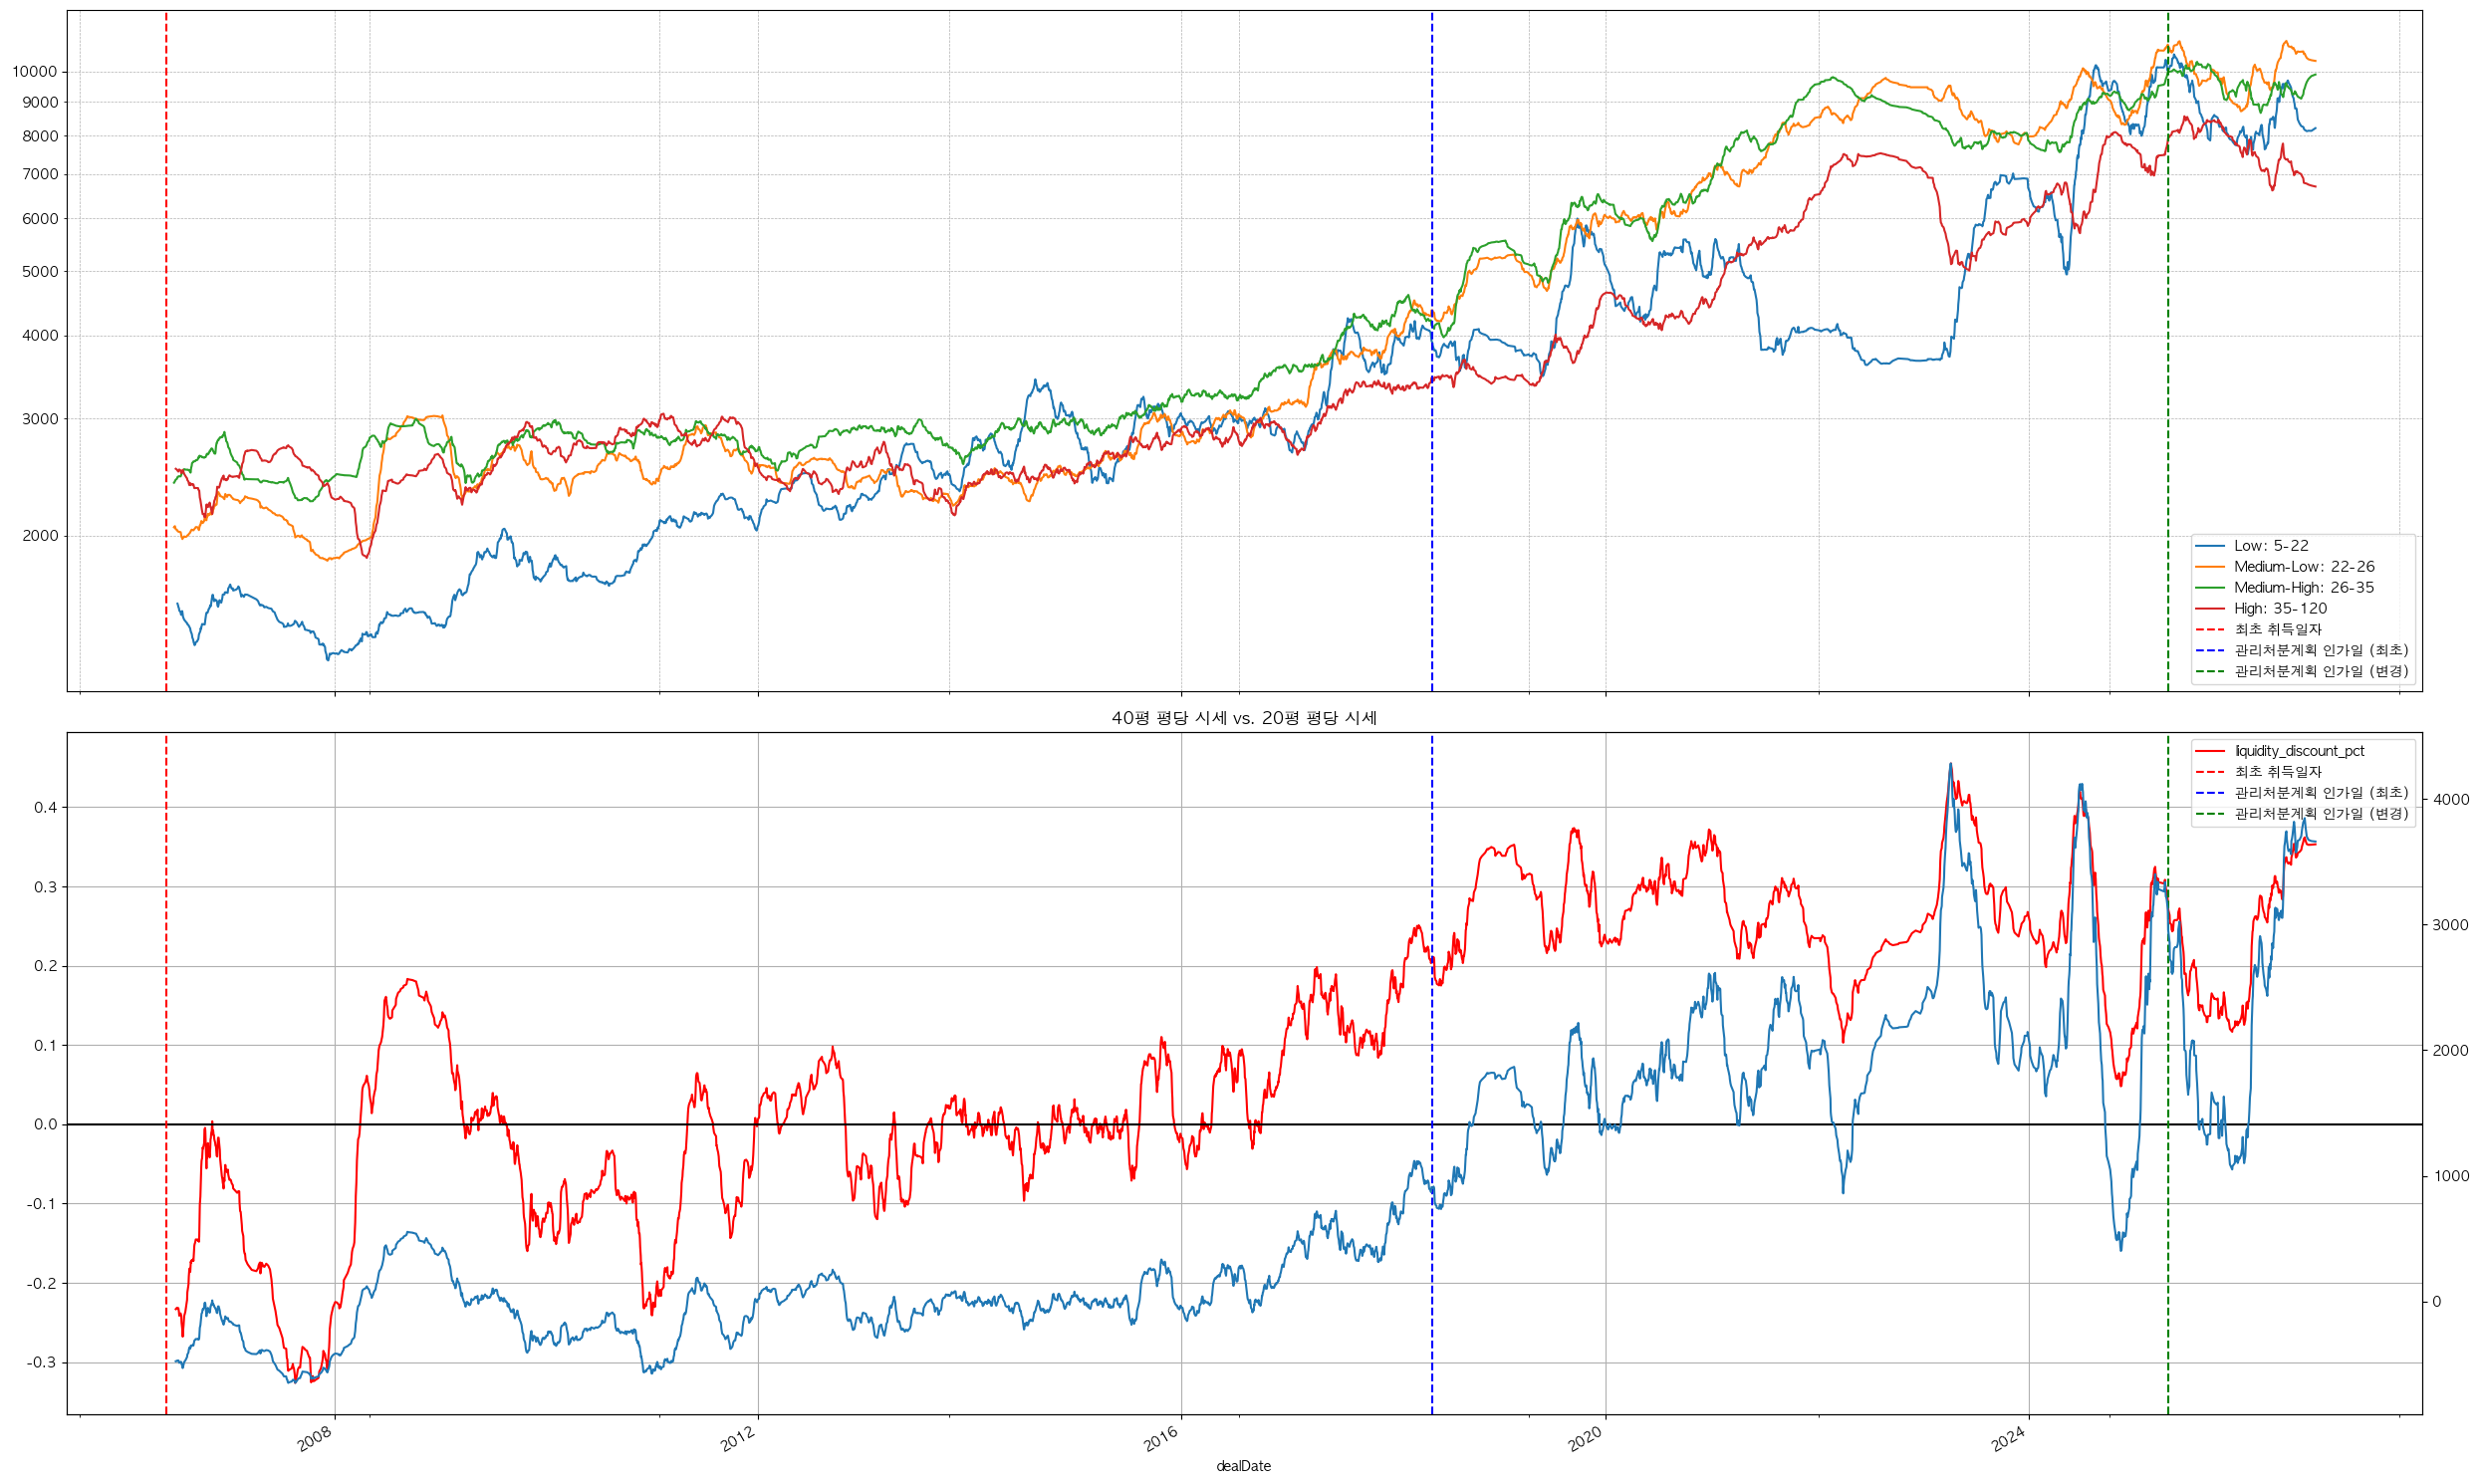

In [84]:
seocho_ppp_by_pyung = (
    df_filtered.pivot_table(index='dealDate', columns=['평_group_qcut'], values='평당_실거래가', aggfunc='median')
    .ffill()
    .rolling(window=90).mean()
)

fig,ax = plt.subplots(2,1, figsize=(25, 15), sharex=True)


seocho_ppp_by_pyung.plot(ax=ax[0])
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)  # Shows major & minor log gridlines
ax[0].set_yscale('log')
ax[0].yaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].yaxis.set_minor_formatter(ticker.ScalarFormatter())

ax1 = ax[1].twinx()
ax[1].set_title('40평 평당 시세 vs. 20평 평당 시세')
seocho_ppp_by_pyung['liquidity_discount_abs'] = seocho_ppp_by_pyung['Medium-Low: 22-26'] - seocho_ppp_by_pyung['High: 35-120']
seocho_ppp_by_pyung['liquidity_discount_pct'] =  1 - seocho_ppp_by_pyung['High: 35-120'] / seocho_ppp_by_pyung['Medium-Low: 22-26']
seocho_ppp_by_pyung['liquidity_discount_pct'].plot(ax=ax[1], c='red')
seocho_ppp_by_pyung['liquidity_discount_abs'].plot(ax=ax1)
ax[1].axhline(0, c='black')
ax[1].grid()

purchase_date = pd.to_datetime('2006-06-01')
permit1_date = pd.to_datetime('2018-05-15')
permit2_date = pd.to_datetime('2025-04-25')

for i in range(len(ax)):
    ax[i].axvline(purchase_date, c='red', ls='--', label='최초 취득일자')
    ax[i].axvline(permit1_date, c='blue', ls='--', label='관리처분계획 인가일 (최초)')
    ax[i].axvline(permit2_date, c='green', ls='--', label='관리처분계획 인가일 (변경)')
    ax[i].legend()
plt.tight_layout();

display(seocho_ppp_by_pyung.describe())
display(seocho_ppp_by_pyung.loc[[purchase_date, permit1_date, permit2_date], :])

## 서초구 피어그룹 층당 가격 추세

floor_group_qcut,Low: -1-4,Medium-Low: 5-7,Medium-High: 8-12,High: 13-46,floor_discount_abs,floor_discount_pct
count,4350.000000,4356.000000,4356.000000,4351.000000,4350.000000,4350.000000
mean,3767.521810,3867.916386,3967.898125,4618.168994,102.660838,0.020728
std,1790.326509,1871.762230,1914.931807,2803.033314,501.324423,0.091429
min,1734.210550,1656.726300,1692.239421,1258.515449,-1598.175739,-0.315037
25%,2434.203575,2576.835418,2586.897384,2678.224201,-105.302993,-0.030122
50%,2948.461581,2936.359760,2969.270400,3170.837950,85.525390,0.028165
75%,4896.833646,5150.034150,5327.113635,6456.405622,228.563307,0.079362
max,8728.983463,10210.404075,9654.142338,11810.820962,3110.253633,0.304616


floor_group_qcut,Low: -1-4,Medium-Low: 5-7,Medium-High: 8-12,High: 13-46,floor_discount_abs,floor_discount_pct
dealDate,,,,,,
2006-06-01,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-15,3333.933458,3951.154294,3931.272841,4715.834589,617.220835,0.156213
2025-04-25,8313.765605,8630.140979,8617.821706,11102.314784,316.375374,0.036659


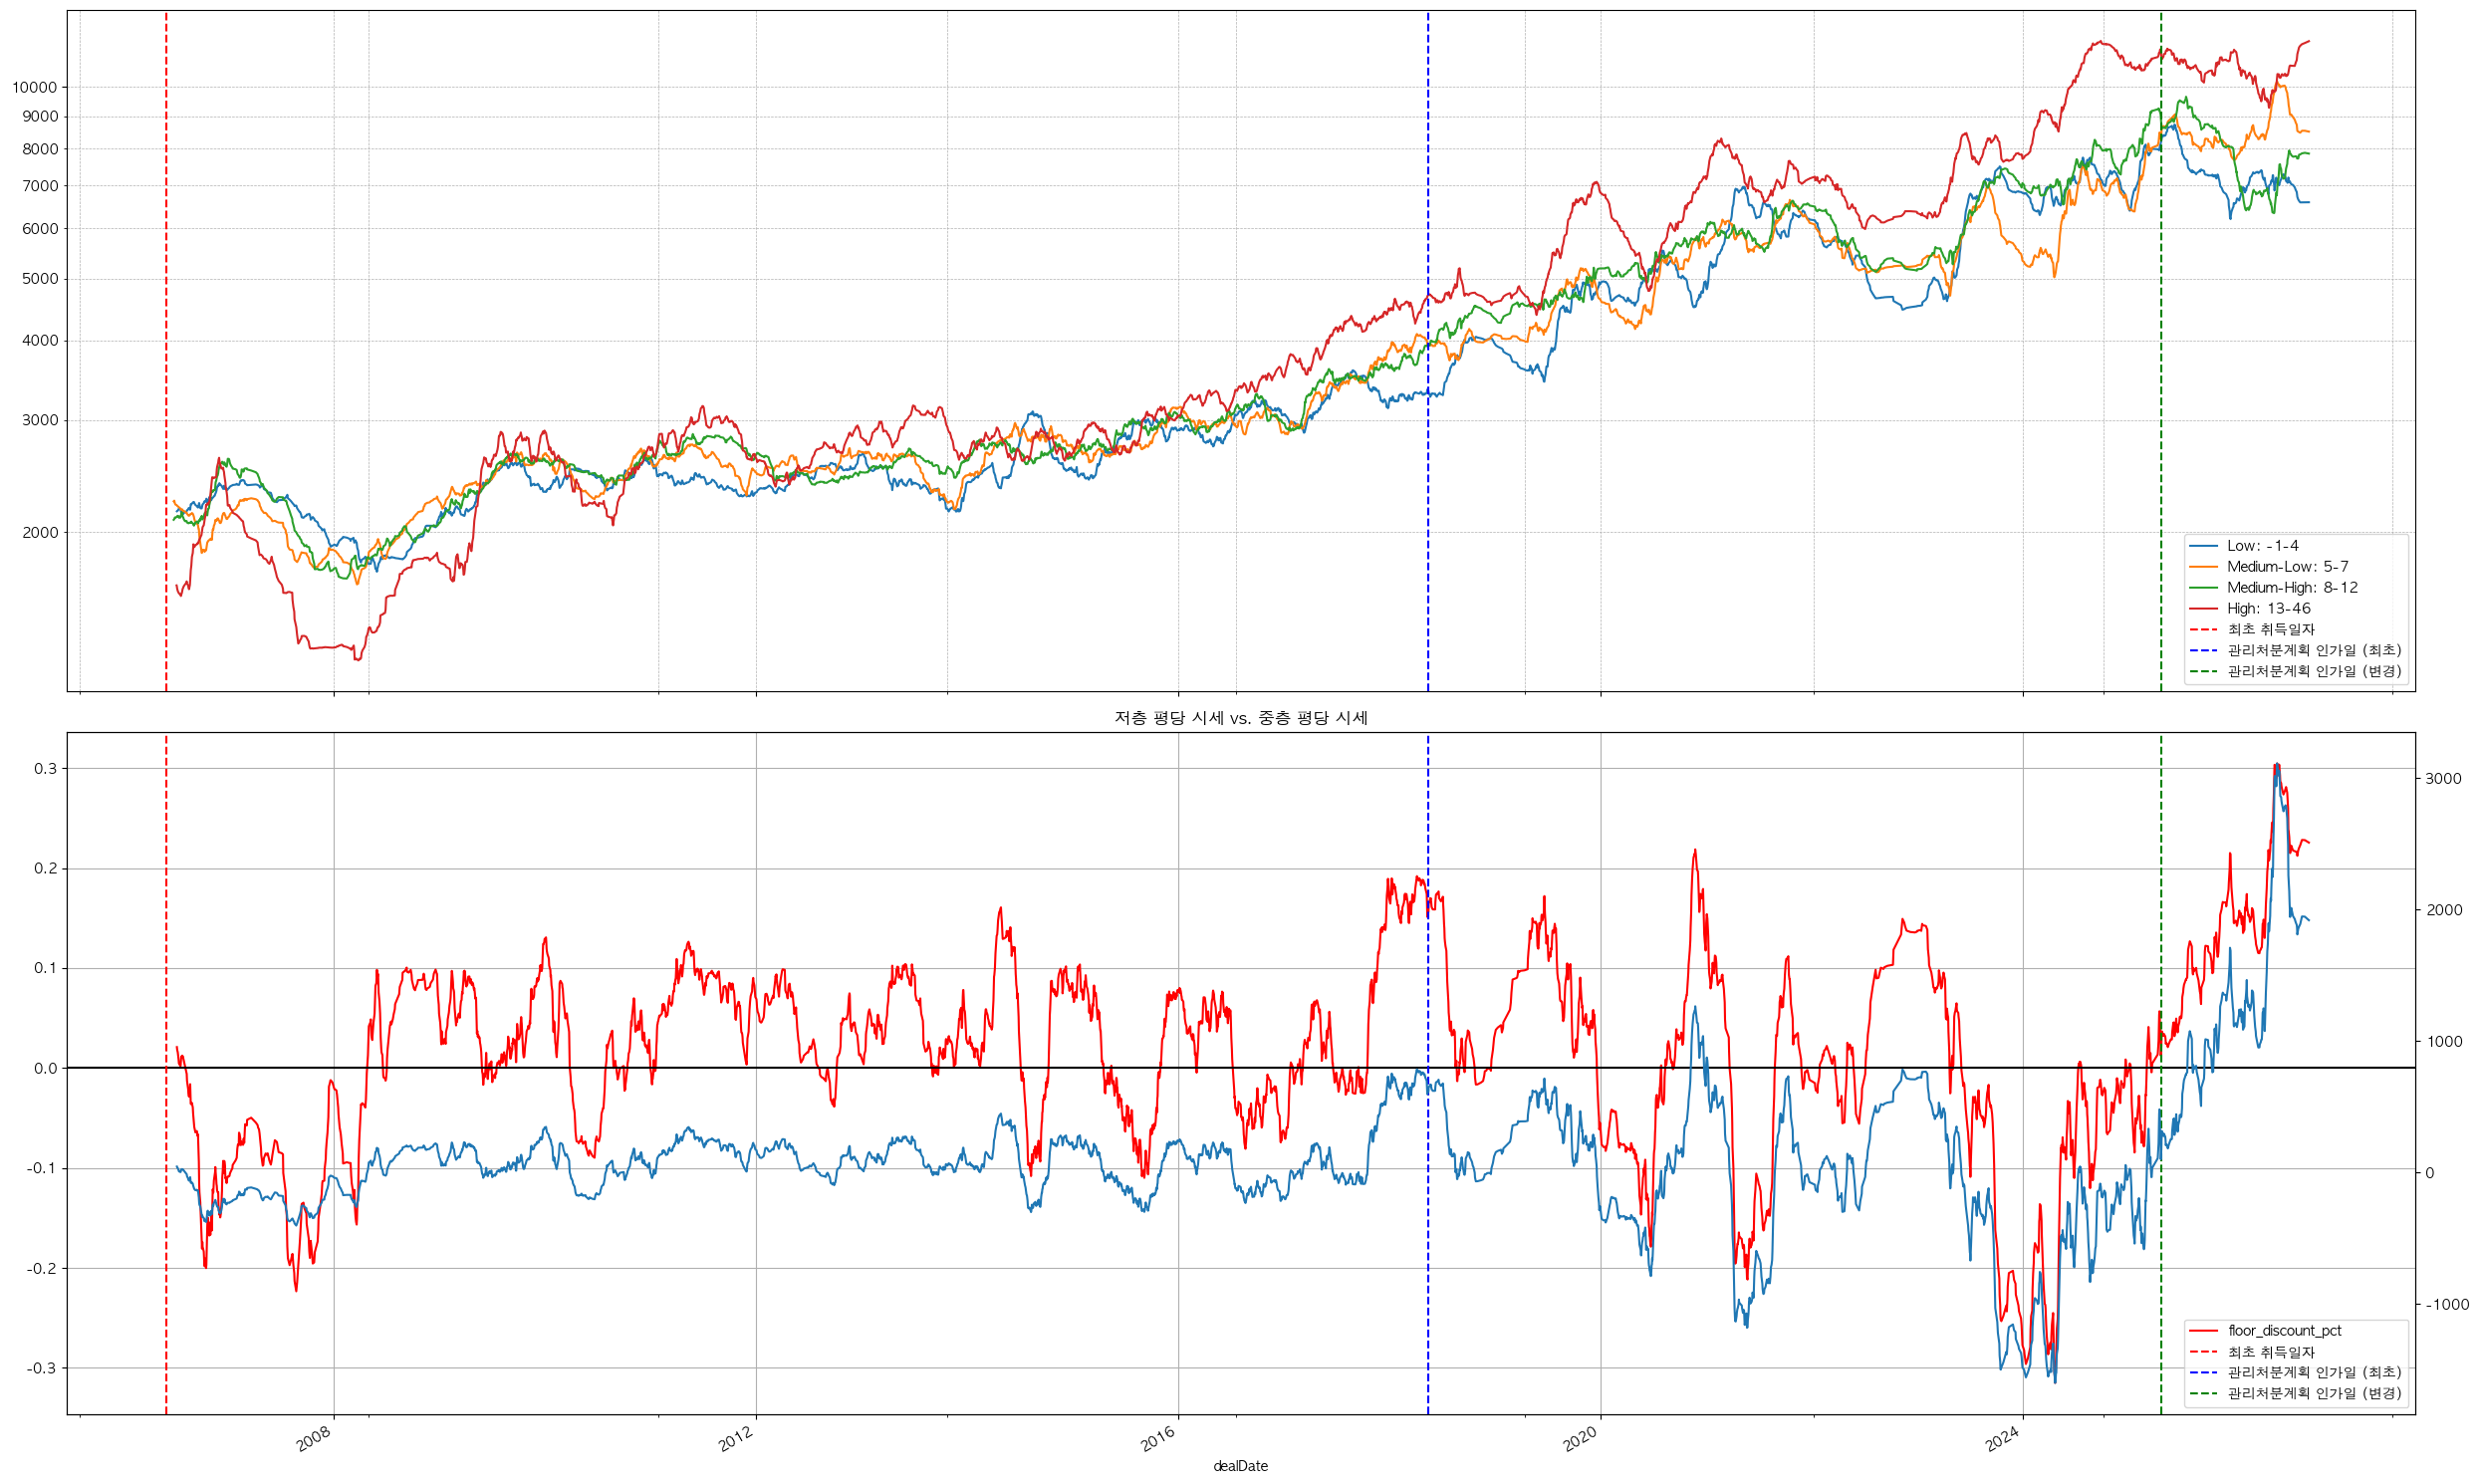

In [87]:
seocho_ppp_by_floor = (
    df_filtered.pivot_table(index='dealDate', columns=['floor_group_qcut'], values='평당_실거래가', aggfunc='median')
    .ffill()
    .rolling(window=90).mean()
)


fig,ax = plt.subplots(2,1, figsize=(25, 15), sharex=True)


seocho_ppp_by_floor.plot(ax=ax[0])
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)  # Shows major & minor log gridlines
ax[0].set_yscale('log')
ax[0].yaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].yaxis.set_minor_formatter(ticker.ScalarFormatter())

ax1 = ax[1].twinx()
ax[1].set_title('저층 평당 시세 vs. 중층 평당 시세')
seocho_ppp_by_floor['floor_discount_abs'] = seocho_ppp_by_floor['Medium-Low: 5-7'] - seocho_ppp_by_floor['Low: -1-4']
seocho_ppp_by_floor['floor_discount_pct'] =  1 - seocho_ppp_by_floor['Low: -1-4'] / seocho_ppp_by_floor['Medium-Low: 5-7']
seocho_ppp_by_floor['floor_discount_pct'].plot(ax=ax[1], c='red')
seocho_ppp_by_floor['floor_discount_abs'].plot(ax=ax1)
ax[1].axhline(0, c='black')
ax[1].grid()

purchase_date = pd.to_datetime('2006-06-01')
permit1_date = pd.to_datetime('2018-05-15')
permit2_date = pd.to_datetime('2025-04-25')

for i in range(len(ax)):
    ax[i].axvline(purchase_date, c='red', ls='--', label='최초 취득일자')
    ax[i].axvline(permit1_date, c='blue', ls='--', label='관리처분계획 인가일 (최초)')
    ax[i].axvline(permit2_date, c='green', ls='--', label='관리처분계획 인가일 (변경)')
    ax[i].legend()
plt.tight_layout();

display(seocho_ppp_by_floor.describe())
display(seocho_ppp_by_floor.loc[[purchase_date, permit1_date, permit2_date], :])

In [89]:
seocho_ppp = (
    df_filtered.pivot_table(index='dealDate', values='평당_실거래가', aggfunc='median')
    .ffill()
    .rolling(window=90).mean()
)['평당_실거래가']

ppp_pnl = seocho_ppp.iloc[-1] - seocho_ppp.loc[permit2_date]
ppp_pnl

-216.49338931896818

In [91]:
# 롱: 4층, 숏: 6층 스프레드
층_long_pnl = seocho_ppp_by_floor['Low: -1-4'].iloc[-1] - seocho_ppp_by_floor.loc[permit2_date, 'Low: -1-4']
층_short_pnl = -1 * (seocho_ppp_by_floor['Medium-Low: 5-7'].iloc[-1] - seocho_ppp_by_floor.loc[permit2_date, 'Medium-Low: 5-7'])
층_spread_pnl = 층_long_pnl + 층_short_pnl
층_spread_pnl

-1601.9660743272589

In [93]:
# 롱: 40평, 숏: 20평 스프레드
평_long_pnl = seocho_ppp_by_pyung['High: 35-120'].iloc[-1] - seocho_ppp_by_pyung.loc[permit2_date, 'High: 35-120']
평_short_pnl = -1 * (seocho_ppp_by_pyung['Medium-Low: 22-26'].iloc[-1] - seocho_ppp_by_pyung.loc[permit2_date, 'Medium-Low: 22-26'])
평_spread_pnl = 평_long_pnl + 평_short_pnl
평_spread_pnl

-566.0251937536632

In [95]:
층_spread_pnl + 평_spread_pnl

-2167.991268080922

In [92]:
# df_combined[
#     (
#         (df_combined.aptNm.str.contains('신동아'))
#         | (df_combined.aptNm.str.contains('그랑자이'))
#         | (df_combined.aptNm.str.contains('우성'))
#         | (df_combined.aptNm.str.contains('무지개'))
#         | (df_combined.aptNm.str.contains('래미안'))
#     ) & (
#         (~df_combined.aptNm.str.contains('반포'))
#         & (~df_combined.aptNm.str.contains('방배'))
#         & (~df_combined.aptNm.str.contains('래미안원베일리'))
#         & (~df_combined.aptNm.str.contains('래미안원펜타스'))
#     )
# ].roadNm.value_counts(normalize=True)
# #.aptNm.value_counts(normalize=True)

# df_combined[df_combined.roadNm.str.contains('서초대로')]


# df_combined[
#     (
#         (df_combined.roadNm.str.contains('사임당로'))
#         | (df_combined.roadNm.str.contains('효령로'))
#         | (df_combined.roadNm.str.contains('서운로'))
#     )
# ].aptNm.value_counts(normalize=True)

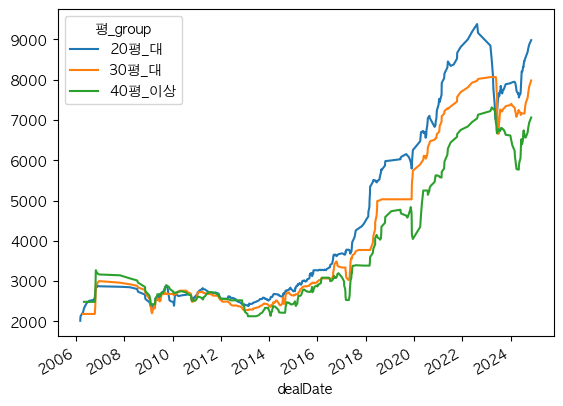

In [94]:
shindongah_ppp_by_pyung = (
    df_combined[df_combined.aptSeq.isin(['11650-53', '11650-484'])].pivot_table(index='dealDate', columns=['평_group'], values='평당_실거래가', aggfunc='median')
    .ffill()
    .rolling(window=7).mean()
)

shindongah_ppp_by_pyung.plot();

In [96]:
shindonga = df_combined[df_combined.aptSeq.isin(['11650-53', '11650-484'])]
#.groupby(['dealDate', 'floor'])['평당_실거래가'].mean()

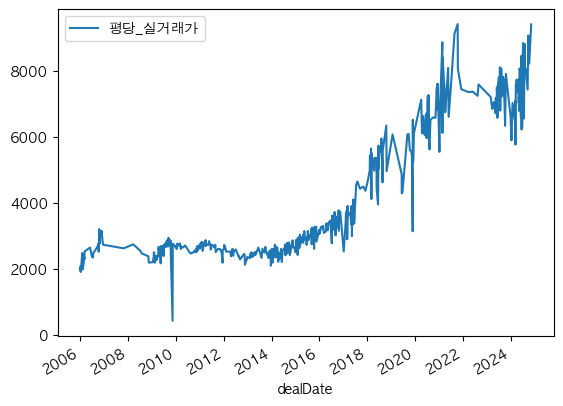

In [98]:
shindonga.pivot_table(index='dealDate', values='평당_실거래가', aggfunc='mean').ffill().plot();